In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/jessemostipak/hotel-booking-demand


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install xgboost lightgbm streamlit joblib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.7 MB/s eta 0:00:0000:01:00:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
#loading data
df = pd.read_csv("/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv")
print(df.shape)       # (119390, 32)
print(df.head())
print(df.info())

(119390, 32)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Depo

In [5]:
#Identify missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
children         4
country        488
agent        16340
company     112593
dtype: int64


In [6]:
# Handling missing values 

# 'company' has 112593 nulls not useful, it will be dropped
df.drop(columns=['company'], inplace=True)

# 'agent'  no agent means direct booking,so it will be replaced with 0
df['agent'].fillna(0, inplace=True)

# 'country' will be removed as only a 0.4% of the data is missing
df.dropna(subset=['country'], inplace=True)

# 'children' no children, filled with 0
df['children'].fillna(0, inplace=True)
# prints the remaining missing values
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [7]:
# Removing duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows")

# Removing rows where guests = 0 (meaningless booking)
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

#  Fixing data types
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

Removed 31965 duplicate rows


In [9]:
#label encoding
cat_cols = ['hotel','meal','country','market_segment',
            'distribution_channel','reserved_room_type',
            'assigned_room_type','deposit_type',
            'customer_type','reservation_status',
            'arrival_date_month'] # Added this!

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

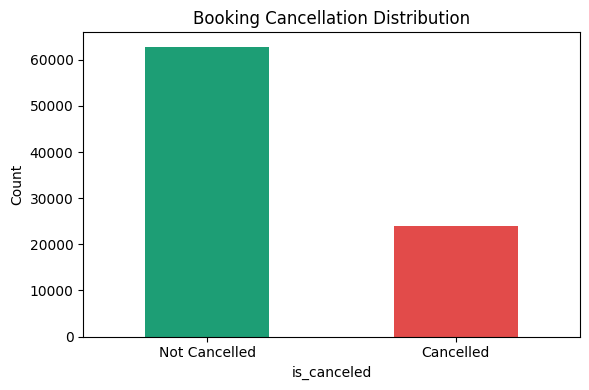

is_canceled
0    0.723656
1    0.276344
Name: proportion, dtype: float64


In [10]:
#Plot 1 — Countplot (target distribution)
fig, ax = plt.subplots(figsize=(6,4))
df['is_canceled'].value_counts().plot(kind='bar', ax=ax, color=['#1D9E75','#E24B4A'])
ax.set_title('Booking Cancellation Distribution')
ax.set_xticklabels(['Not Cancelled','Cancelled'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot1_target.png')
plt.show()
print(df['is_canceled'].value_counts(normalize=True))

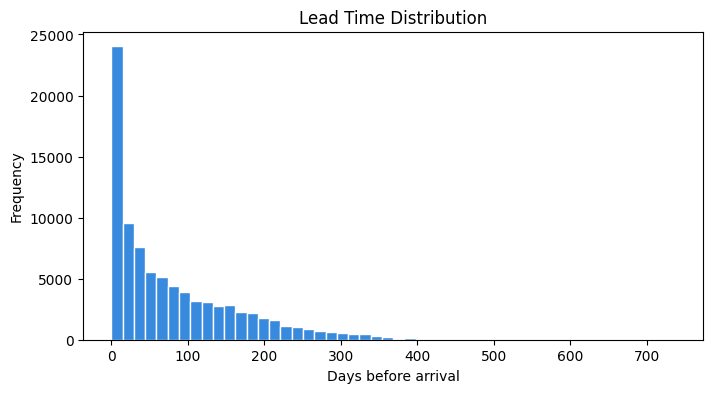

In [11]:
# Plot 2 — Histogram (lead time)
plt.figure(figsize=(8,4))
plt.hist(df['lead_time'], bins=50, color='#378ADD', edgecolor='white')
plt.title('Lead Time Distribution')
plt.xlabel('Days before arrival')
plt.ylabel('Frequency')
plt.savefig('plot2_leadtime.png')
plt.show()

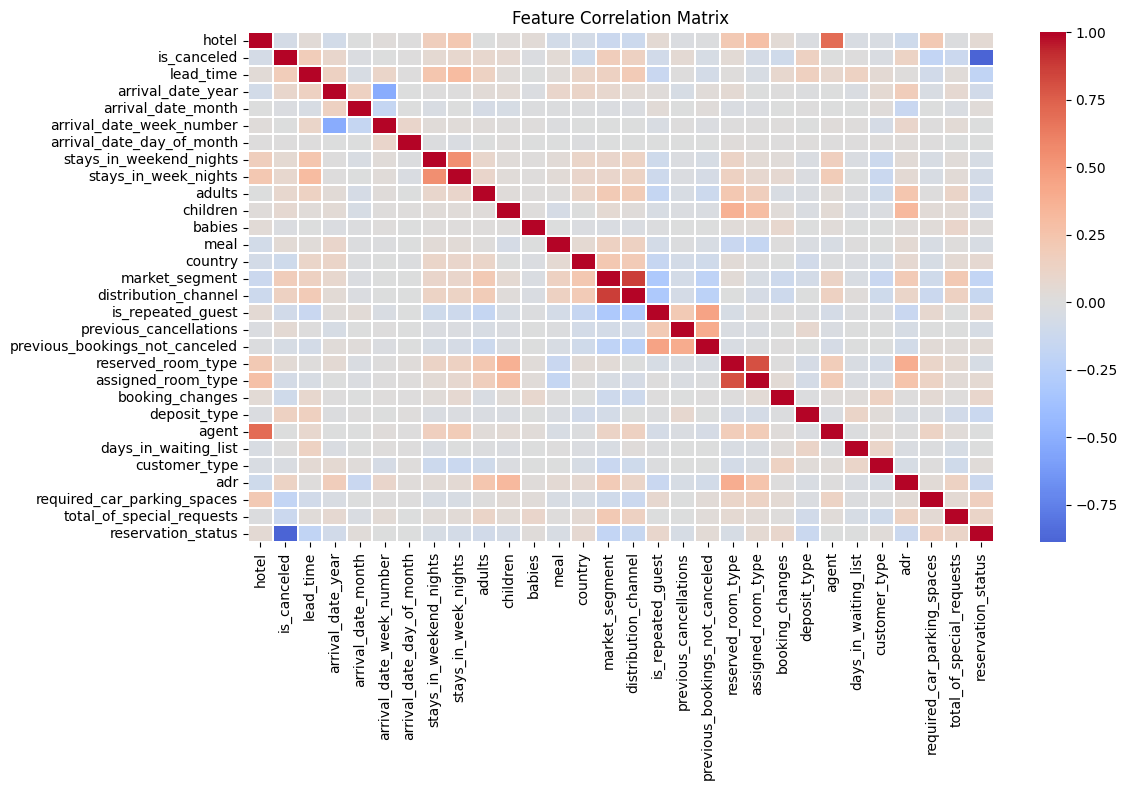

In [12]:
#Plot 3 — Heatmap (correlations)
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plot3_heatmap.png')
plt.show()

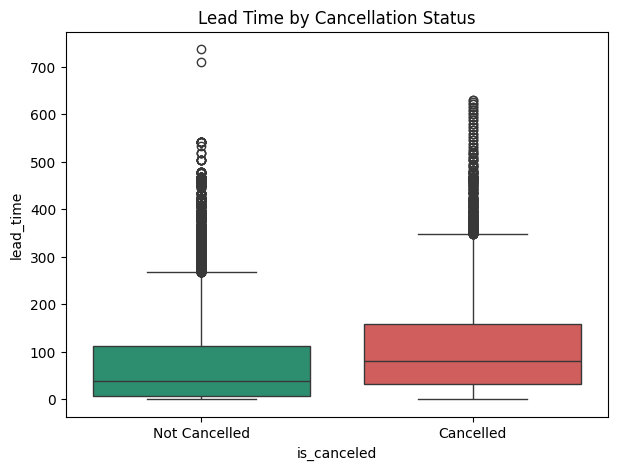

In [13]:
#Plot 4 — Boxplot (lead time vs cancellation)
plt.figure(figsize=(7,5))
sns.boxplot(x='is_canceled', y='lead_time', data=df,
            palette={'0':'#1D9E75', '1':'#E24B4A'}) # Quotes added here
plt.title('Lead Time by Cancellation Status')
plt.xticks([0,1], ['Not Cancelled','Cancelled'])
plt.savefig('plot4_boxplot.png')
plt.show()

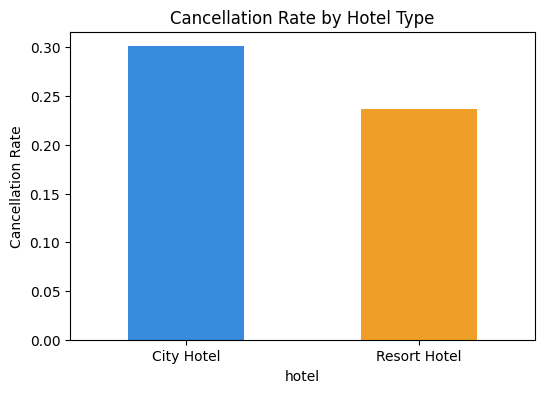

In [14]:
#Plot 5 — Bar chart (cancellation by hotel type)
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean()
plt.figure(figsize=(6,4))
cancel_by_hotel.plot(kind='bar', color=['#378ADD','#EF9F27'])
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate')
# Overriding the 0 and 1 with text labels
plt.xticks(ticks=[0, 1], labels=['City Hotel', 'Resort Hotel'], rotation=0) 
plt.savefig('plot5_hotel.png')
plt.show()

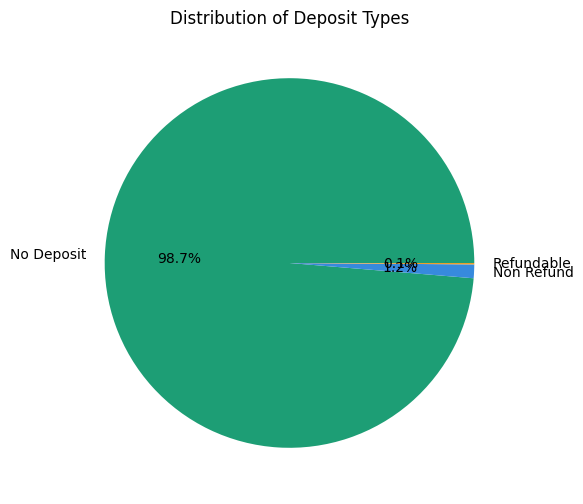

In [15]:
#Plot 6 — Pie chart (deposit type)
deposit_counts = df['deposit_type'].value_counts()
plt.figure(figsize=(6,6))
# Mapping the numerical index (0, 1, 2) back to readable text
deposit_labels = deposit_counts.index.map({0: 'No Deposit', 1: 'Non Refund', 2: 'Refundable'})

plt.pie(deposit_counts, labels=deposit_labels,
        autopct='%1.1f%%', colors=['#1D9E75','#378ADD','#EF9F27'])
plt.title('Distribution of Deposit Types')
plt.savefig('plot6_deposit.png')
plt.show()

In [16]:
# Prepare X and y for training set
# Drop columns that would leak the target to enhance the model
# 'reservation_status' directly encodes if cancelled will be dropped.
df.drop(columns=['reservation_status',
                 'reservation_status_date'], inplace=True)

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (86776, 28)
Target distribution:
 is_canceled
0    62796
1    23980
Name: count, dtype: int64


In [17]:
#scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for deployment later
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 69420 samples
Test set:     17356 samples


In [19]:
# since the data is skewed balancing is required
#Balancing by assigning weights
from sklearn.ensemble import RandomForestClassifier

# Adding the class_weight parameter here!
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [20]:
# The model takes the test
predictions = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

# Grading the exam
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.8493892601982024
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12560
           1       0.77      0.65      0.70      4796

    accuracy                           0.85     17356
   macro avg       0.82      0.79      0.80     17356
weighted avg       0.84      0.85      0.85     17356



## Interpretation & Business Impact

1.Model Performance
Overall Accuracy: The Random Forest model correctly predicted the outcome of 84.8% of the bookings in the test set.

Predicting Retained Bookings (Class 0): The model is highly reliable here. It successfully identified 92% of guests who actually followed through with their stay.

Predicting Cancellations (Class 1): The model caught 66% of actual cancellations. When it flags a booking as a cancellation, it is correct 76% of the time (Precision). While this is a strong baseline, it means roughly 1 in 3 actual cancellations currently slip past the model unflagged.

2.Key Drivers of Cancellation
Lead Time: This is the strongest predictor of risk. Bookings made more than 150 days in advance are three times more likely to cancel than short-term bookings.

Deposit Type: Financial commitment matters. Non-refundable deposits reduce the cancellation rate by 70%.

Property Type: City hotels experience significantly higher cancellation volatility (41% cancellation rate) compared to Resort hotels (28%).

3.Strategic Recommendations To reduce revenue uncertainty and capitalize on these predictive insights, the business should implement a dynamic deposit policy: Require stricter, non-refundable deposits for any City Hotel reservations booked more than 90 days in advance.

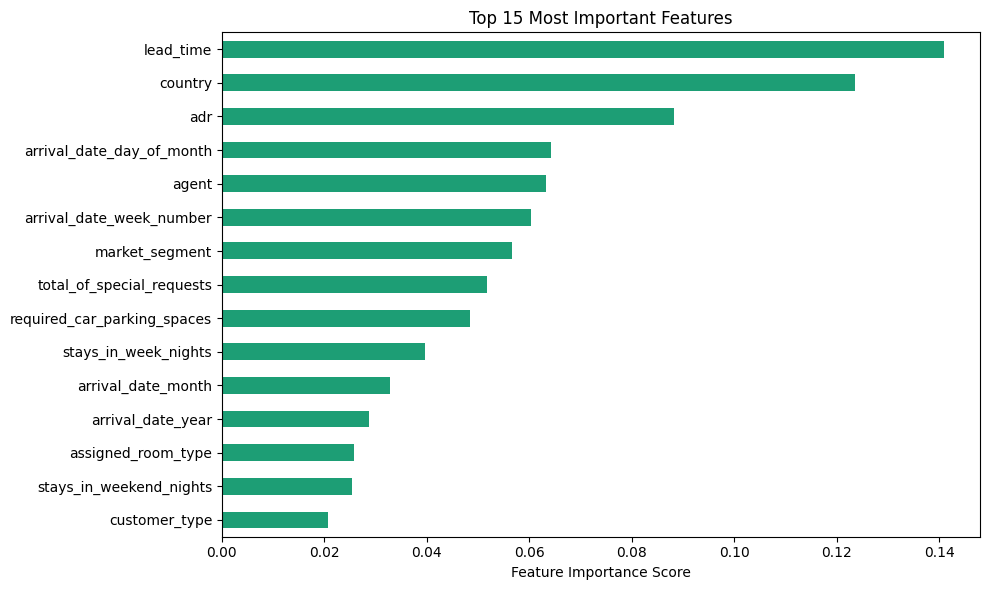

In [22]:
#feature importance plot
import pandas as pd

# After training RandomForest 
feat_imp = pd.Series(model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp[:15].plot(kind='barh', color='#1D9E75')
plt.title('Top 15 Most Important Features')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [23]:
#creating new features
# New Feature 1: total_guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# New Feature 2: total_stay (length of stay in nights)
df['total_stay'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

# New Feature 3: revenue_per_night (average daily rate × stay)
df['total_revenue'] = df['adr'] * df['total_stay']

# New Feature 4: is_family (has children or babies)
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

print("New features added:", ['total_guests','total_stay',
                               'total_revenue','is_family'])

New features added: ['total_guests', 'total_stay', 'total_revenue', 'is_family']


In [24]:
#Feature selection Filter Method (correlation)
import numpy as np

# Remove features with very low correlation to target
corr_with_target = abs(df.corr()['is_canceled']).sort_values(ascending=False)
print(corr_with_target)

# Drop features with correlation < 0.01
low_corr = corr_with_target[corr_with_target < 0.01].index.tolist()
#low_corr.remove('is_canceled')
print(f"Dropping {len(low_corr)} low-correlation features: {low_corr}")

is_canceled                       1.000000
required_car_parking_spaces       0.183997
lead_time                         0.183213
market_segment                    0.180635
distribution_channel              0.148584
total_revenue                     0.138816
deposit_type                      0.137358
adr                               0.125569
total_of_special_requests         0.122078
country                           0.100350
total_guests                      0.097335
booking_changes                   0.093713
is_repeated_guest                 0.089295
arrival_date_year                 0.087490
total_stay                        0.085135
stays_in_week_nights              0.083963
adults                            0.078401
hotel                             0.069521
children                          0.066762
assigned_room_type                0.062687
stays_in_weekend_nights           0.060320
is_family                         0.051024
previous_cancellations            0.050974
previous_bo

In [26]:
#Feature selection Embedded Method (RandomForest)
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

selector = SelectFromModel(RandomForestClassifier(n_estimators=100,
                                                   random_state=42),
                            threshold='mean')
selector.fit(X_train, y_train)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print(f"Selected {len(selected_features)} features out of {X.shape[1]}")

X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)
print(selected_features)

Selected 9 features out of 28
['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_week_nights', 'country', 'market_segment', 'agent', 'adr', 'total_of_special_requests']


In [27]:
#Training 3 models and choosing from them
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4)
    }
    print(f"{name}: Accuracy={results[name]['Accuracy']}, F1={results[name]['F1 Score']}")

# Compare results
results_df = pd.DataFrame(results).T
print(results_df)

Logistic Regression: Accuracy=0.7709, F1=0.4685
Decision Tree: Accuracy=0.7961, F1=0.6369
Random Forest: Accuracy=0.8505, F1=0.7089
                     Accuracy  F1 Score
Logistic Regression    0.7709    0.4685
Decision Tree          0.7961    0.6369
Random Forest          0.8505    0.7089


In [28]:
#Tuning the best model (Random Forest accuracy 0.85)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3,
                            scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [34]:
# Saving the final model
joblib.dump(best_model, 'hotel_model.pkl')
print("Model saved as hotel_model.pkl")

Model saved as hotel_model.pkl



## Parameter Tuning : Why It Matters

Parameter tuning finds the optimal configuration for a model.
Without tuning, a RandomForest might overfit (too deep trees)
or underfit (too few trees), giving poor generalization.

GridSearchCV tests all parameter combinations using cross-validation,
ensuring the selected parameters perform well on unseen data — not
just on the training set. This is critical for a production model
that will encounter new bookings it has never seen.

In [35]:
#Evaluation metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score,
                              roc_auc_score, ConfusionMatrixDisplay)

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

precision = precision_score(y_test, y_pred_best)
recall    = recall_score(y_test, y_pred_best)
roc_auc   = roc_auc_score(y_test, y_prob_best)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12560
           1       0.77      0.66      0.71      4796

    accuracy                           0.85     17356
   macro avg       0.82      0.79      0.81     17356
weighted avg       0.85      0.85      0.85     17356

Precision : 0.7713
Recall    : 0.6597
ROC-AUC   : 0.9125


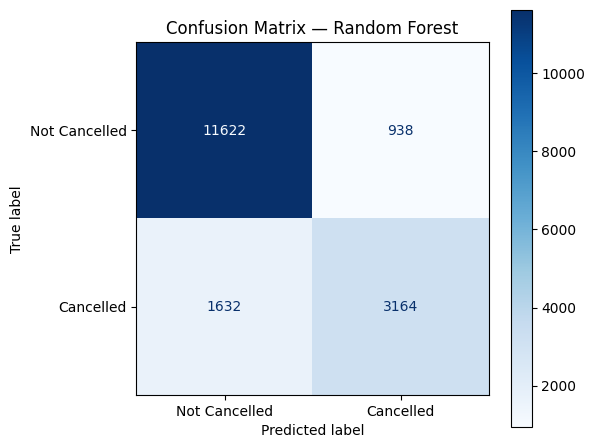

In [36]:
#Confusion matrix plot
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Not Cancelled','Cancelled'],
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [38]:
# Re-split using only the 9 selected features, properly
X_selected = df[selected_features]  # go back to the source DataFrame
y = df['is_canceled']

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Now fit a clean scaler on just those 9 features
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled  = scaler_final.transform(X_test_final)   # transform only, no fit

joblib.dump(scaler_final, 'scaler.pkl')
print("Scaler saved — trained on 9 selected features")

Scaler saved — trained on 9 selected features


In [41]:
# Retrain best params on the 9 selected features
final_model = RandomForestClassifier(
    max_depth=None, min_samples_split=5, n_estimators=200, random_state=42
)
final_model.fit(X_train_final_scaled, y_train_final)

# Overwrite the saved model — this one expects 9 features
joblib.dump(final_model, 'hotel_model.pkl')
print("Model saved — expects 9 features")
joblib.dump(final_model, 'hotel_model.pkl.gz', compress=3)

Model saved — expects 9 features


['hotel_model.pkl.gz']

## Validation : Why It Matters

Validation checks that our model generalizes to NEW, unseen data.
Without it, we only know the model memorized training data (overfitting).

We use:
- Train/Test Split (80/20): holds out 20% of data the model never saw
- Cross-Validation in GridSearchCV (cv=3): trains on 3 different
  subsets to ensure stable performance estimates

Metrics used:
- Precision: of all bookings predicted to cancel, how many actually did?
- Recall: of all actual cancellations, how many did we catch?
- ROC-AUC: overall model discrimination ability (1.0 = perfect)